# Wine Classification with Tree-Based Models

This notebook builds a classification pipeline for the scikit-learn Wine dataset. The workflow covers data loading, exploratory inspection, preprocessing, model selection with cross-validation, and final evaluation on a held-out test set.

In [1]:
import sys
sys.path.append("..")
from utils.utils import * 
from sklearn.datasets import load_wine
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline, Pipeline
from scipy.stats import randint, uniform, loguniform
from IPython.display import Markdown, display
import matplotlib.pyplot as plt

## Data Loading

Load the Wine dataset and split it into a feature matrix `X` and target vector `y`.

In [2]:
wine = load_wine()

X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name="target")

## Full Dataset Inspection

Inspect the complete dataset to understand the feature schema, missing values, feature distributions, and class balance before creating the train-test split.

### Initial Feature Preview

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


### Initial Target Preview

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

### Feature Missing-Value Check

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64

### Target Missing-Value Check

np.int64(0)

### Feature Schema Summary

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: fl

### Target Schema Summary

<class 'pandas.core.series.Series'>
RangeIndex: 178 entries, 0 to 177
Series name: target
Non-Null Count  Dtype
--------------  -----
178 non-null    int64
dtypes: int64(1)
memory usage: 1.5 KB


### Feature Distributions

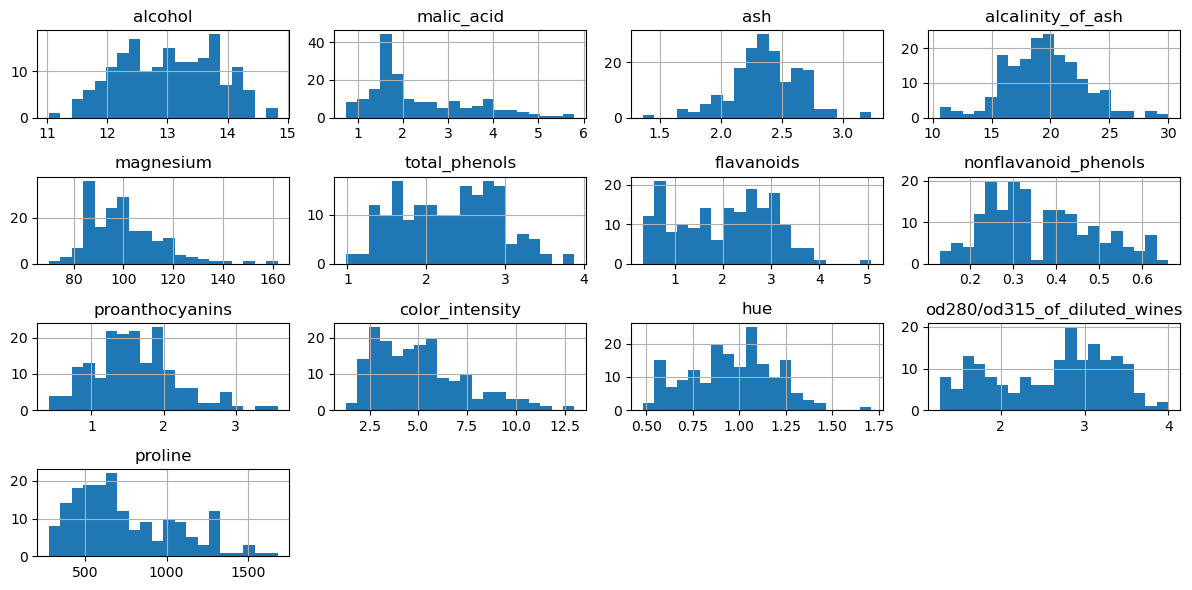

### Class Distribution

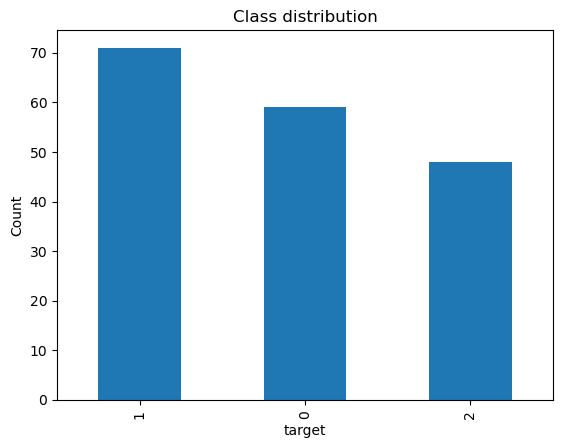

In [3]:
display(Markdown("### Initial Feature Preview"))
display(X.head())
display(Markdown("### Initial Target Preview"))
display(y.head())
display(Markdown("### Feature Missing-Value Check"))
display(X.isnull().sum())
display(Markdown("### Target Missing-Value Check"))
display(y.isnull().sum())
display(Markdown("### Feature Schema Summary"))
X.info()
display(Markdown("### Target Schema Summary"))
y.info()
display(Markdown("### Feature Distributions"))
X.hist(figsize=(12, 6), bins=20)
plt.tight_layout()
plt.show()
display(Markdown("### Class Distribution"))
y.value_counts().plot(kind="bar")
plt.ylabel("Count")
plt.title("Class distribution")
plt.show()

## Training Dataset Inspection

After the train-test split, inspect only the training data. Any preprocessing decisions should be based on the training set to avoid leaking information from the test set.

### Initial Feature Preview

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
138,13.49,3.59,2.19,19.5,88.0,1.62,0.48,0.58,0.88,5.70,0.81,1.82,580.0
104,12.51,1.73,1.98,20.5,85.0,2.20,1.92,0.32,1.48,2.94,1.04,3.57,672.0
78,12.33,0.99,1.95,14.8,136.0,1.90,1.85,0.35,2.76,3.40,1.06,2.31,750.0
36,13.28,1.64,2.84,15.5,110.0,2.60,2.68,0.34,1.36,4.60,1.09,2.78,880.0
93,12.29,2.83,2.22,18.0,88.0,2.45,2.25,0.25,1.99,2.15,1.15,3.30,290.0


### Initial Target Preview

138    2
104    1
78     1
36     0
93     1
Name: target, dtype: int64

### Feature Missing-Value Check

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64

### Target Missing-Value Check

np.int64(0)

### Feature Schema Summary

<class 'pandas.core.frame.DataFrame'>
Index: 124 entries, 138 to 102
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       124 non-null    float64
 1   malic_acid                    124 non-null    float64
 2   ash                           124 non-null    float64
 3   alcalinity_of_ash             124 non-null    float64
 4   magnesium                     124 non-null    float64
 5   total_phenols                 124 non-null    float64
 6   flavanoids                    124 non-null    float64
 7   nonflavanoid_phenols          124 non-null    float64
 8   proanthocyanins               124 non-null    float64
 9   color_intensity               124 non-null    float64
 10  hue                           124 non-null    float64
 11  od280/od315_of_diluted_wines  124 non-null    float64
 12  proline                       124 non-null    float64
dtypes: float

### Target Schema Summary

<class 'pandas.core.series.Series'>
Index: 124 entries, 138 to 102
Series name: target
Non-Null Count  Dtype
--------------  -----
124 non-null    int64
dtypes: int64(1)
memory usage: 1.9 KB


### Feature Distributions

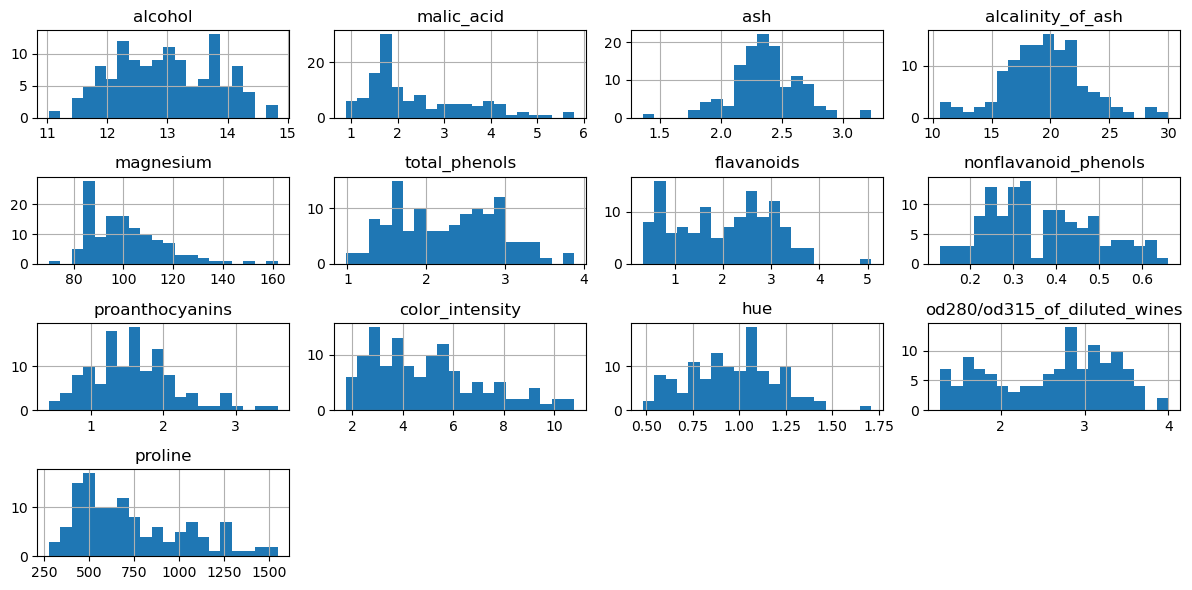

### Class Distribution

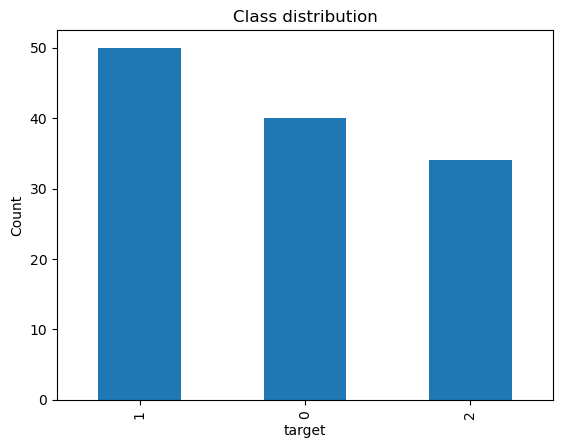

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
display(Markdown("### Initial Feature Preview"))
display(X_train.head())
display(Markdown("### Initial Target Preview"))
display(y_train.head())
display(Markdown("### Feature Missing-Value Check"))
display(X_train.isnull().sum())
display(Markdown("### Target Missing-Value Check"))
display(y_train.isnull().sum())
display(Markdown("### Feature Schema Summary"))
X_train.info()
display(Markdown("### Target Schema Summary"))
y_train.info()
display(Markdown("### Feature Distributions"))
X_train.hist(figsize=(12, 6), bins=20)
plt.tight_layout()
plt.show()
display(Markdown("### Class Distribution"))
y_train.value_counts().plot(kind="bar")
plt.ylabel("Count")
plt.title("Class distribution")
plt.show()

## Preprocessing

Create a preprocessing pipeline for the numeric features. Standardization is included so every candidate model receives features on a comparable scale.

In [5]:
num_pipeline = make_pipeline(
    StandardScaler()
)

preprocessing = ColumnTransformer([
    ("num", num_pipeline, X_train.columns),
])

## Model Selection

Compare decision trees and tree-based ensemble models with randomized hyperparameter search. The best pipeline is selected using macro-averaged F1 score across cross-validation folds.

In [6]:
pipe = Pipeline([
    ("preprocessing", preprocessing),
    ("model", BaggingClassifier())
])

alphas = [0, 0.005, 0.01, 0.02, 0.05, 0.1]
depths = [3, 5, 8, 12, 20]

param_distribution = [
    {
        "model": [
            DecisionTreeClassifier(random_state=42)
        ],
        "model__ccp_alpha": alphas,
        "model__max_depth": depths
    },
    {
        "model": [
            BaggingClassifier(
                estimator=DecisionTreeClassifier(random_state=42),
                random_state=42,
                n_jobs=-1
                )
            ],
        "model__n_estimators": randint(50, 401),
        "model__estimator__ccp_alpha": alphas,
        "model__estimator__max_depth": depths

    },
    {
        "model": [RandomForestClassifier(
            random_state=42,
            n_jobs=-1
        )],
        "model__n_estimators": randint(50, 401),
        "model__max_depth": depths

    },
    {
        "model": [GradientBoostingClassifier(
            random_state=42
        )],
        "model__n_estimators": randint(50, 501),
        "model__learning_rate": loguniform(0.01, 0.3),
        "model__max_depth": depths
    }
]

rnd = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_distribution,
    scoring="f1_macro",
    cv=5,
    random_state=42,
    n_jobs=-1,
    n_iter=80
)


rnd.fit(X_train, y_train)

best_model = rnd.best_estimator_
display(Markdown("### Cross-Validation Scores"))
display(rnd.cv_results_["mean_test_score"])
display(Markdown("### Best Selected Pipeline"))
best_model

### Cross-Validation Scores

array([0.96906089, 0.96906089, 0.9340985 , 0.96906089, 0.9340985 ,
       0.9536933 , 0.90687842, 0.89500789, 0.9536933 , 0.93463353,
       0.96906089, 0.90513776, 0.96906089, 0.93463353, 0.96906089,
       0.96906089, 0.93127615, 0.9536933 , 0.93127615, 0.96906089,
       0.9340985 , 0.92331078, 0.96144184, 0.92331078, 0.96906089,
       0.92331078, 0.96906089, 0.96144184, 0.88707139, 0.9340985 ,
       0.96906089, 0.9340985 , 0.96906089, 0.96906089, 0.9420479 ,
       0.96906089, 0.90513776, 0.89500789, 0.93463353, 0.96906089,
       0.93463353, 0.93463353, 0.87878529, 0.9340985 , 0.96906089,
       0.96906089, 0.93463353, 0.96144184, 0.90469786, 0.90469786,
       0.90513776, 0.96144184, 0.90469786, 0.93463353, 0.96144184,
       0.96906089, 0.96144184, 0.9536933 , 0.89500789, 0.96144184,
       0.90513776, 0.9340985 , 0.88672179, 0.95220663, 0.93463353,
       0.96144184, 0.95362164, 0.90513776, 0.95362164, 0.92331078,
       0.96144184, 0.92331078, 0.96906089, 0.88672179, 0.92331

### Best Selected Pipeline

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Final Evaluation

Evaluate the selected model on the held-out test set to estimate its performance on unseen data.

Accuracy: 1.0

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        14

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54

Confusion matrix:



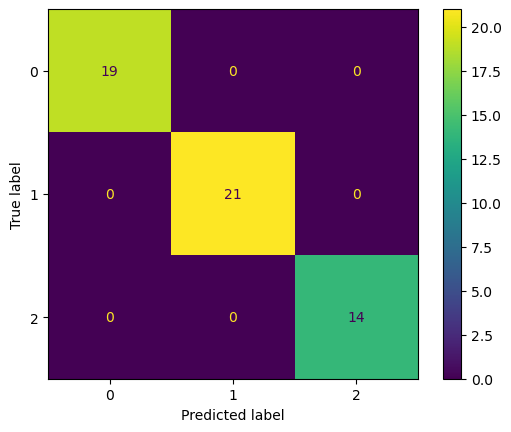

In [7]:
evaluate_classification(best_model, X_test, y_test)